<a href="https://www.kaggle.com/code/ahmedelsany/sentiment-analysis-bilstm?scriptVersionId=301477863" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Import Required Libraries

In this section, we import the libraries needed for:
- Data manipulation
- Text preprocessing
- Deep learning model building using TensorFlow/Keras
- Model evaluation

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import os
import re


In [2]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

from sklearn.metrics import accuracy_score

2026-03-04 20:55:34.056277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772657734.390915      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772657734.480405      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772657735.255500      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772657735.255564      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772657735.255568      17 computation_placer.cc:177] computation placer alr

In [3]:
# Download necessary resources
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Data Exploration

Before building the model, we explore the dataset to understand:
- Number of samples
- Class distribution
- Text examples

This helps identify possible data imbalance or preprocessing needs.

In [4]:
train_data = pd.read_csv(
    '/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/train.csv',
    encoding='latin-1'
)

train_data.head(10)

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,neutral,night,70-100,Antigua and Barbuda,97929,440.0,223
6,6e0c6d75b1,2am feedings for the baby are fun when he is a...,fun,positive,morning,0-20,Argentina,45195774,2736690.0,17
7,50e14c0bb8,Soooo high,Soooo high,neutral,noon,21-30,Armenia,2963243,28470.0,104
8,e050245fbd,Both of you,Both of you,neutral,night,31-45,Australia,25499884,7682300.0,3
9,fc2cbefa9d,Journey!? Wow... u just became cooler. hehe....,Wow... u just became cooler.,positive,morning,46-60,Austria,9006398,82400.0,109


In [5]:
test_data = pd.read_csv('/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/test.csv', encoding='latin1')
test_data.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [6]:
test_data.shape

(4815, 9)

In [7]:
train_data.shape

(27481, 10)

In [8]:
train_data["sentiment"].value_counts()

sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

In [9]:
test_data["sentiment"].value_counts()

sentiment
neutral     1430
positive    1103
negative    1001
Name: count, dtype: int64

In [10]:
train_data.duplicated().sum()

np.int64(0)

In [11]:
train_data.drop_duplicates(inplace=True)

In [12]:
train_data.shape

(27481, 10)

In [13]:
train_data.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [14]:
train_data.isna().sum()

textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

In [15]:
train_data.dropna(inplace=True)

In [16]:
test_data.isna().sum()

textID              1281
text                1281
sentiment           1281
Time of Tweet       1281
Age of User         1281
Country             1281
Population -2020    1281
Land Area (Km²)     1281
Density (P/Km²)     1281
dtype: int64

In [17]:
test_data.dropna(inplace=True)

<Axes: >

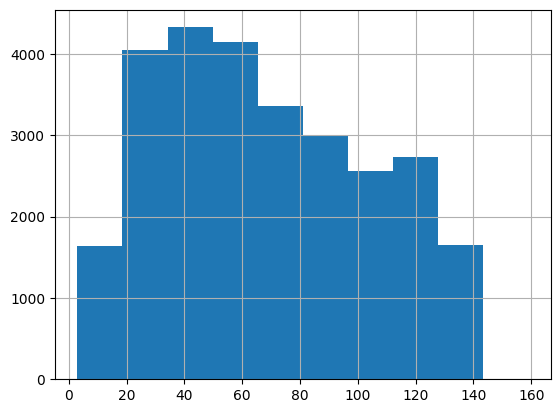

In [18]:
train_data.text.apply(lambda x: len(x)).hist()

## Text Preprocessing

In this step we clean and prepare the text data by:
- Lowercasing text
- Removing punctuation
- Removing unnecessary characters
- Preparing text for tokenization

In [19]:
import re 
from nltk.tokenize import word_tokenize  
from nltk.corpus import stopwords  
from nltk.stem import WordNetLemmatizer ,PorterStemmer

# Load English stop words into a set for faster lookup
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess_text(text):
    
    # Return empty string if the value is missing (NaN)
    if pd.isna(text):
        return ""
    
    # Convert input to string and lowercase it
    text = str(text).lower()
    
    # Remove URLs, mentions, and hashtags
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", " ", text)
    
    # Keep only English letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Tokenize the text into words
    tokens = word_tokenize(text)
    
    # Lemmatize each token
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    # tokens = [stemmer.stem(w) for w in tokens]


    # Remove common stop words
    tokens = [w for w in tokens if w not in stop_words]
    
    # Join tokens back into a cleaned sentence
    return " ".join(tokens)

# Apply preprocessing to the text column and create a new cleaned_text column
train_data["cleaned_text"] = train_data["text"].apply(preprocess_text)
test_data["cleaned_text"] = test_data["text"].apply(preprocess_text)


In [20]:
test_data.shape ,train_data.shape

((3534, 10), (27480, 11))

In [21]:
train_data.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),cleaned_text
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60,responded going
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105,sooo sad miss san diego
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18,bos bullying
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164,interview leave alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26,son put release already bought


In [22]:
from sklearn.model_selection import train_test_split

X_train_text = train_data["cleaned_text"].values

y_train_raw = train_data[["sentiment"]].values

X_test_text = test_data["cleaned_text"].values

y_test_raw = test_data[["sentiment"]].values

X_train_text.shape ,y_train_raw.shape , X_test_text.shape ,y_test_raw.shape

((27480,), (27480, 1), (3534,), (3534, 1))

In [23]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=  False)

y_train_enc = encoder.fit_transform(y_train_raw)
y_test_enc = encoder.transform(y_test_raw)  


## Tokenization

Text data cannot be directly used in deep learning models.

We convert words into numerical representations using **Tokenizer**, which builds a vocabulary and assigns an integer index to each word.

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenization and Padding
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train_text) 

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)



## Padding Sequences

Since sentences have different lengths, we use **padding** to make all sequences the same length.

This ensures the model can process the input data efficiently.

In [25]:
max_len = max(len(seq) for seq in X_train_seq)

X_train_padded = pad_sequences(X_train_seq, padding='pre', maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, padding='pre', maxlen=max_len)

In [26]:
max_len

22

In [27]:
len(X_train_text[1].split()),X_train_text[1]

(5, 'sooo sad miss san diego')

In [28]:
X_test_seq[1]

[157, 19, 754, 3, 1528, 2005, 4514]

In [29]:
X_train_padded[1]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,  300,   53,   36, 1269, 2049],
      dtype=int32)

## Building the BiLSTM Model

We build a deep learning architecture using:

- Embedding Layer
- Bidirectional LSTM
- SimpleRNN
- Batch Normalization
- Dropout layers for regularization
- Dense layers for classification

In [30]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100
vocab_size

21327

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.2)),
    Dropout(0.3),
    Dense(y_train_enc.shape[1], activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)
]

history = model.fit(
    X_train_padded, y_train_enc,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_padded, y_test_enc),
    callbacks=callbacks
)

Epoch 1/20


2026-03-04 20:56:12.019935: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


430/430 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.5318 - loss: 0.9474 - val_accuracy: 0.7015 - val_loss: 0.6896 - learning_rate: 0.0010
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.7456 - loss: 0.6380 - val_accuracy: 0.7207 - val_loss: 0.6662 - learning_rate: 0.0010
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - accuracy: 0.7739 - loss: 0.5691 - val_accuracy: 0.7184 - val_loss: 0.6835 - learning_rate: 0.0010
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.7959 - loss: 0.5238 - val_accuracy: 0.7134 - val_loss: 0.7052 - learning_rate: 0.0010
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 32s 74ms/step - accuracy: 0.8114 - loss: 0.4928 - val_accuracy: 0.7168 - val_loss: 0.7166 - learning_rate: 0.0010
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.8322 - loss: 0.4477 - val_accuracy: 0.7097 - val_loss: 0.7729 - learning_rate: 0.0010
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.8466 - loss: 0.4124

In [32]:
print(f"Training accuracy:\t{history.history['accuracy'][-1]*100:.2f} %")
print(f"Validation accuracy:\t{history.history['val_accuracy'][-1]*100:.2f} %")

Training accuracy:	83.74 %
Validation accuracy:	70.51 %


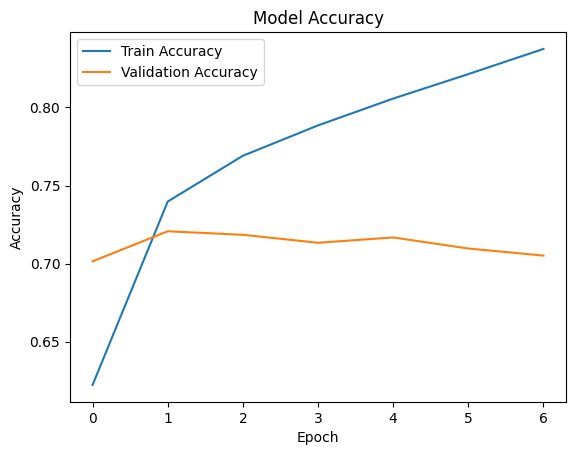

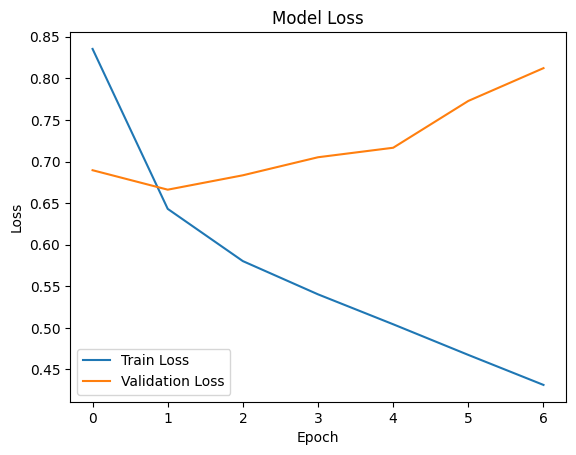

In [33]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()


# Loss Plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [34]:
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, SimpleRNN, Dropout, Dense, BatchNormalization
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

bi_rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),

    Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)),  
    BatchNormalization(),
    Dropout(0.3),

    Bidirectional(SimpleRNN(64, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(y_train_enc.shape[1], activation="softmax")
])

bi_rnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bi_rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Train the model
history_2 = bi_rnn_model.fit(
    X_train_padded, y_train_enc,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_padded, y_test_enc),
    callbacks=callbacks
)

Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 43s 83ms/step - accuracy: 0.3591 - loss: 0.8659 - val_accuracy: 0.4666 - val_loss: 0.5985 - learning_rate: 1.0000e-04
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.4801 - loss: 0.6816 - val_accuracy: 0.6457 - val_loss: 0.5017 - learning_rate: 1.0000e-04
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 36s 84ms/step - accuracy: 0.5952 - loss: 0.5672 - val_accuracy: 0.6794 - val_loss: 0.4683 - learning_rate: 1.0000e-04
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 37s 85ms/step - accuracy: 0.6713 - loss: 0.4953 - val_accuracy: 0.6950 - val_loss: 0.4459 - learning_rate: 1.0000e-04
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 81ms/step - accuracy: 0.7163 - loss: 0.4455 - val_accuracy: 0.6995 - val_loss: 0.4356 - learning_rate: 1.0000e-04
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.7409 - loss: 0.4094 - val_accuracy: 0.7026 - val_loss: 0.4409 - learning_rate: 1.0000e-04
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 34s 80ms/ste

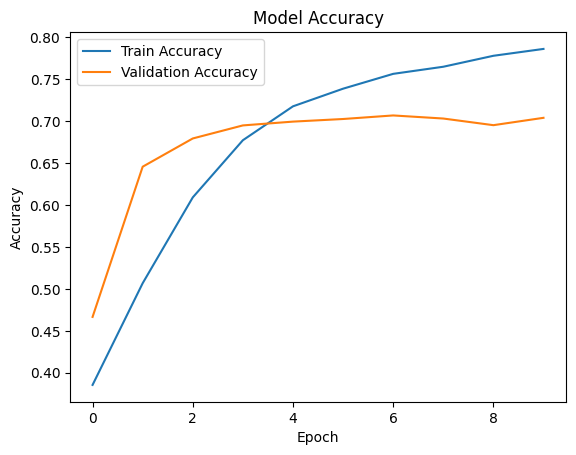

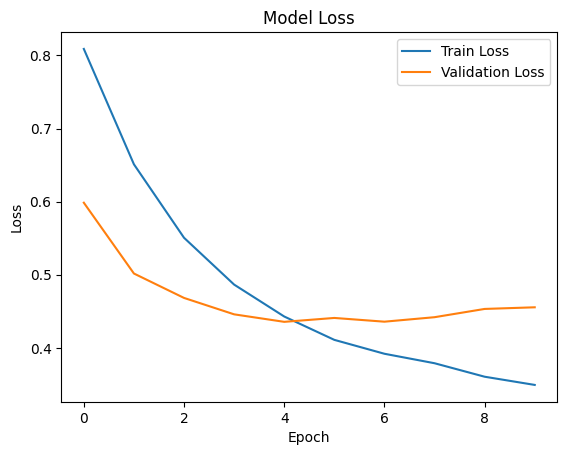

In [36]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure()
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()


# Loss Plot
plt.figure()
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

## Model Predictions

Finally, we test the model on new text inputs to see how well it predicts sentiment.

In [37]:
# Prediction 1
text = "The movie was bad bad bad, i will not recommend this movie to anyone"

new_text = "I absolutely loved the movie but the ending was bad."

new_seq = tokenizer.texts_to_sequences([new_text])

new_padded = pad_sequences(new_seq, padding="pre", maxlen=max_len)

pred_probs = bi_rnn_model.predict(new_padded)

pred_label = encoder.inverse_transform(pred_probs)

print(pred_label[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
['positive']


## Conclusion

The BiLSTM-based model achieved good performance for sentiment classification.  
Future improvements could include:

- Using pretrained embeddings (GloVe / Word2Vec)
- Using Transformer models like BERT
- Hyperparameter tuning